# LayerNorm: Per-Sample Normalization and Why Transformers Love It

BatchNorm is great for CNNs, but it has a fundamental problem for sequential models:
the normalization statistics depend on the *batch*, but in transformers, different
positions in a sequence have very different statistical properties — and batch size 1
is often used at inference time.

**LayerNorm** (Ba et al., 2016) fixes this by normalizing across the **feature dimension**
instead of the batch dimension. Each sample is normalized independently.


In [1]:
import sys; sys.path.insert(0, '../src')
import torch, torch.nn as nn
import numpy as np, matplotlib.pyplot as plt
%matplotlib inline

from norms import LayerNormManual, check_gradients
from visualize import (plot_gradient_check, plot_training_curves,
                       plot_activation_distributions, plot_normalization_geometry)
from train import make_dataset, compare_norms, NormMLP


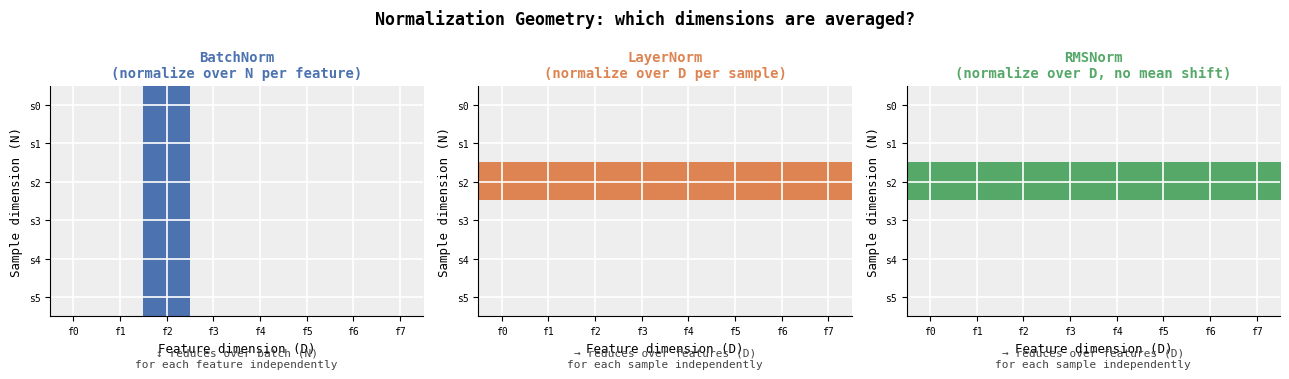

In [2]:
# The key geometric difference: which dimension do we normalize over?
fig = plot_normalization_geometry(n_samples=6, n_features=8)
plt.show()


## 1. Forward Pass

Given input $X \in \mathbb{R}^{N \times D}$, for **each sample** $i$:

$$\mu_i = \frac{1}{D} \sum_{j=1}^{D} x_{ij} \quad \text{(per-sample mean)}$$

$$\sigma^2_i = \frac{1}{D} \sum_{j=1}^{D} (x_{ij} - \mu_i)^2$$

$$\hat{x}_{ij} = \frac{x_{ij} - \mu_i}{\sqrt{\sigma^2_i + \epsilon}}$$

$$y_{ij} = \gamma_j \hat{x}_{ij} + \beta_j$$

Notice: $\mu_i$ and $\sigma^2_i$ depend on $i$ (sample index), not $j$ (feature index).
No batch dependency → works identically with batch_size=1.


In [3]:
torch.manual_seed(0)
N, D = 4, 8
x = torch.randn(N, D) * 3 + 2

print("BatchNorm would use column statistics (over N):")
print(f"  mu  shape: {x.mean(0).shape}  (D,)")

print("\nLayerNorm uses row statistics (over D):")
mu_ln  = x.mean(dim=-1, keepdim=True)     # (N, 1)
var_ln = x.var(dim=-1, keepdim=True, unbiased=False)
print(f"  mu  shape: {mu_ln.shape}  (N, 1)")
print(f"  var shape: {var_ln.shape}  (N, 1)")

x_hat_ln = (x - mu_ln) / torch.sqrt(var_ln + 1e-5)
print("\nEach row now has zero mean, unit variance:")
print(f"  row means: {x_hat_ln.mean(-1).tolist()}")
print(f"  row stds:  {x_hat_ln.std(-1).tolist()}")


BatchNorm would use column statistics (over N):
  mu  shape: torch.Size([8])  (D,)

LayerNorm uses row statistics (over D):
  mu  shape: torch.Size([4, 1])  (N, 1)
  var shape: torch.Size([4, 1])  (N, 1)

Each row now has zero mean, unit variance:
  row means: [-1.4901161193847656e-08, 1.4901161193847656e-08, 1.4901161193847656e-08, 1.341104507446289e-07]
  row stds:  [1.0690442323684692, 1.0690438747406006, 1.069044589996338, 1.0690441131591797]


## 2. Manual Backward Pass

Same derivation as BatchNorm, but the reduction axes are swapped:
- BatchNorm sums over `dim=0` (batch)
- LayerNorm sums over `dim=-1` (features)

The five-step derivation is structurally identical. The key difference is
that each sample is *independent* — there are no cross-sample dependencies
in the backward pass, unlike BatchNorm where $\mu$ and $\sigma^2$ mix gradients
across the batch.


In [4]:
torch.manual_seed(1)
N, D = 16, 32
x = torch.randn(N, D)

ln = LayerNormManual(normalized_shape=D)
out = ln.forward(x)
dout = torch.ones_like(out)
dx, d_gamma, d_beta = ln.backward(dout)

results = check_gradients(ln, x)
print("LayerNorm gradient check:")
for k, v in results.items():
    status = '✓ PASS' if (v < 1e-4 if isinstance(v, float) else v) else '✗ FAIL'
    print(f"  {k:<12}: {v}   {status}")


LayerNorm gradient check:
  dx          : 3.5762786865234375e-07   ✓ PASS
  d_gamma     : 1.9073486328125e-06   ✓ PASS
  d_beta      : 0.0   ✓ PASS
  all_pass    : True   ✓ PASS


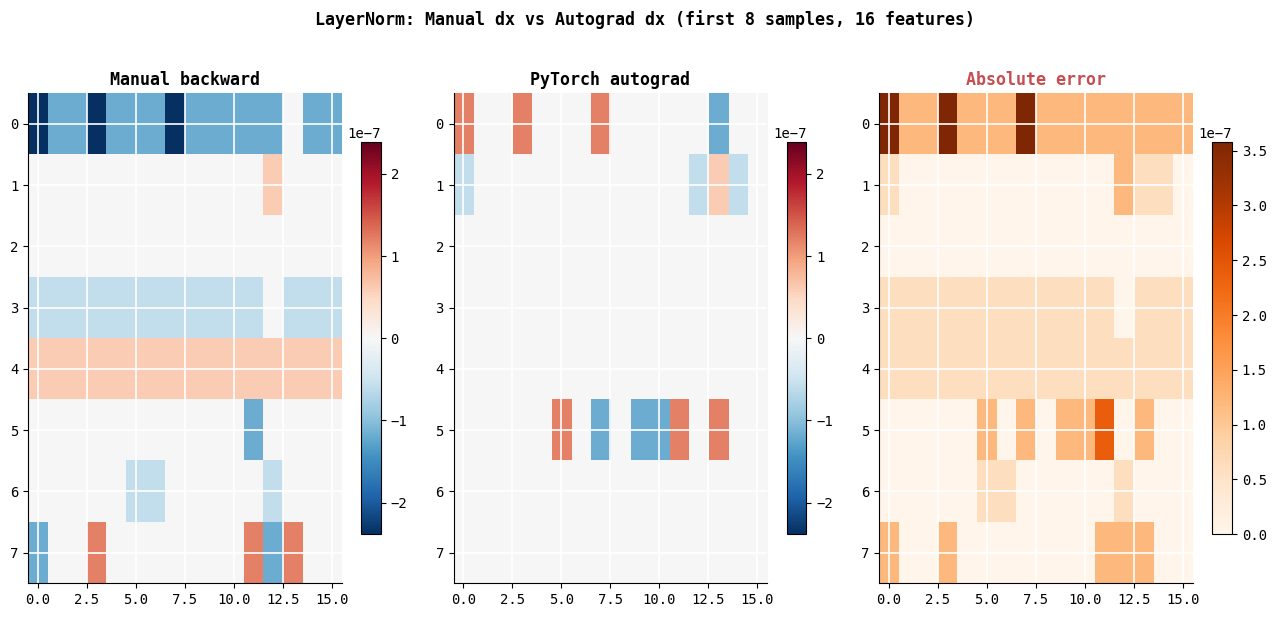

In [5]:
x_auto = x.clone().detach().requires_grad_(True)
torch_ln = nn.LayerNorm(D)
torch_ln.weight.data = ln.gamma.clone()
torch_ln.bias.data   = ln.beta.clone()
out_auto = torch_ln(x_auto); out_auto.sum().backward()

fig = plot_gradient_check(dx[:8, :16], x_auto.grad[:8, :16],
                          title="LayerNorm: Manual dx vs Autograd dx (first 8 samples, 16 features)")
plt.show()


## 3. LayerNorm in Transformers

In a transformer, the input to LayerNorm is typically shape `(batch, seq_len, d_model)`.
PyTorch's `nn.LayerNorm(d_model)` normalizes over the last dimension (d_model).

Why is this ideal?
- Each token position is normalized independently → no information leakage across positions
- Works at seq_len=1 (no sequential dependency on batch stats)
- Stable gradient flow through the residual stream

Let's verify it handles arbitrary batch/sequence shapes.


In [6]:
# Transformer-style input
batch, seq_len, d_model = 2, 10, 64

x_transformer = torch.randn(batch, seq_len, d_model)
torch_ln_transformer = nn.LayerNorm(d_model)
out = torch_ln_transformer(x_transformer)

print(f"Input shape:  {x_transformer.shape}")
print(f"Output shape: {out.shape}")
print(f"Each (batch, position) normalized independently:")
print(f"  out[0, 0] mean: {out[0, 0].mean().item():.6f}")
print(f"  out[0, 1] mean: {out[0, 1].mean().item():.6f}")
print(f"  out[1, 0] mean: {out[1, 0].mean().item():.6f}")


Input shape:  torch.Size([2, 10, 64])
Output shape: torch.Size([2, 10, 64])
Each (batch, position) normalized independently:
  out[0, 0] mean: 0.000000
  out[0, 1] mean: -0.000000
  out[1, 0] mean: -0.000000


## 4. BatchNorm vs LayerNorm — Training Comparison

In [7]:
X, Y = make_dataset(n_samples=2000, n_features=32, n_classes=4, seed=1)

histories = compare_norms(
    {'batchnorm': lambda d: nn.BatchNorm1d(d),
     'layernorm': lambda d: nn.LayerNorm(d),
     'nonorm':    None},
    X, Y, hidden_dim=64, n_layers=4,
    lr=0.05, n_steps=1500, batch_size=32
)



  Training with: batchnorm
step     0 | loss 1.4505
step   100 | loss 0.4572
step   200 | loss 0.3594
step   300 | loss 0.1605
step   400 | loss 0.3021
step   500 | loss 0.2317
step   600 | loss 0.3090
step   700 | loss 0.1117
step   800 | loss 0.2418
step   900 | loss 0.3133
step  1000 | loss 0.1295
step  1100 | loss 0.1131
step  1200 | loss 0.2357
step  1300 | loss 0.2334
step  1400 | loss 0.1381

  Training with: layernorm
step     0 | loss 1.4236
step   100 | loss 0.4084
step   200 | loss 0.1339
step   300 | loss 0.0781
step   400 | loss 0.0846
step   500 | loss 0.0776
step   600 | loss 0.0633
step   700 | loss 0.0281
step   800 | loss 0.0386
step   900 | loss 0.0191
step  1000 | loss 0.0192
step  1100 | loss 0.0120
step  1200 | loss 0.0205
step  1300 | loss 0.0118
step  1400 | loss 0.0115

  Training with: nonorm
step     0 | loss 1.4013
step   100 | loss 0.9813
step   200 | loss 0.3426
step   300 | loss 0.3392
step   400 | loss 0.1686
step   500 | loss 0.1407
step   600 | loss 0

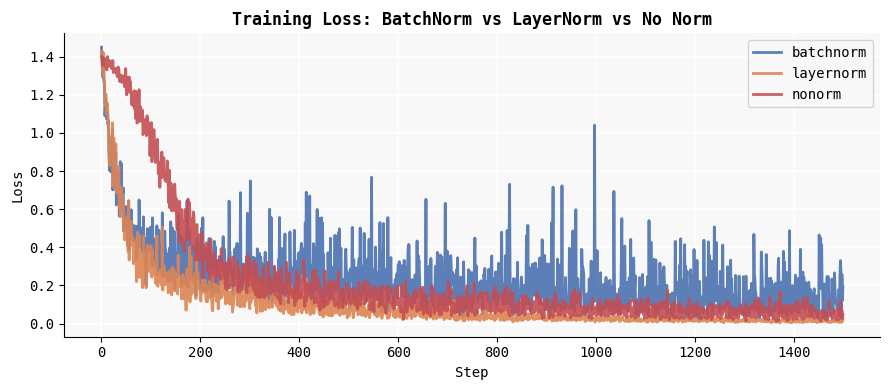

In [8]:
fig = plot_training_curves(
    {k: v['losses'] for k, v in histories.items()},
    title="Training Loss: BatchNorm vs LayerNorm vs No Norm"
)
plt.show()


## 5. Batch Size 1 — Where LayerNorm Wins

At inference in autoregressive generation, we often decode one token at a time
(batch size = 1, sequence of 1). BatchNorm breaks here. LayerNorm is invariant.


In [9]:
x_single = torch.randn(1, 32)

torch_bn = nn.BatchNorm1d(32); torch_bn.eval()
torch_ln = nn.LayerNorm(32)

out_bn = torch_bn(x_single)
out_ln = torch_ln(x_single)

print("Batch size = 1, eval mode:")
print(f"  BatchNorm output mean: {out_bn.mean().item():.4f}  (uses running stats)")
print(f"  LayerNorm output mean: {out_ln.mean().item():.6f}  (always correct)")
print(f"  LayerNorm output std:  {out_ln.std().item():.6f}")


Batch size = 1, eval mode:
  BatchNorm output mean: 0.0988  (uses running stats)
  LayerNorm output mean: 0.000000  (always correct)
  LayerNorm output std:  1.015995


## Summary

| | BatchNorm | LayerNorm |
|---|---|---|
| Normalizes over | N (batch) | D (features) |
| Running stats | Yes (needed for eval) | No |
| Batch size = 1 | Breaks | Works fine |
| Best for | CNNs, large batches | Transformers, RNNs |
| Introduced | 2015 | 2016 |

**Next**: `03_rmsnorm_internals.ipynb` — how LLaMA removed the mean and beta
and still achieved equal (or better) performance.
